![Time Series Analysis](../assets/time_series_banner.png)

# 📈 Time Series Analysis

### Understanding Patterns, Trends & Seasonality

**Python | Pandas | Matplotlib | Statsmodels**

**By Ajim Mujawar**

<a class="anchor" id="0.1"></a>
# **Table of Contents**


1.	[Introduction to Time Series Analysis](#1)
2.	[Types of data](#2)
3.	[Time Series terminology](#3)
4.	[Time Series Analysis](#4)
5.	[Visualize the Time Series](#5)
6.	[Patterns in a Time Series](#6)
7.	[Additive and Multiplicative Time Series](#7)
8.	[Decomposition of a Time Series](#8)
9.	[Stationary and Non-Stationary Time Series](#9)
10.	[How to make a time series stationary](#10)
11.	[How to test for stationarity](#11)
    - 11.1	[Augmented Dickey Fuller test (ADF Test)](#11.1)
    - 11.2	[Kwiatkowski-Phillips-Schmidt-Shin – KPSS test (trend stationary)](#11.2)
    - 11.3	[Philips Perron test (PP Test)](#11.3)
12.	[Difference between white noise and a stationary series](#12)
13.	[Detrend a Time Series](#13)
14.	[Deseasonalize a Time Series](#14)
15.	[How to test for seasonality of a time series](#15)
16.	[Autocorrelation and Partial Autocorrelation Functions](#16)
17.	[Computation of Partial Autocorrelation Function](#17)
18.	[Lag Plots](#18)
19.	[Granger Causality Test](#19)
20.	[Smoothening a Time Series](#20)
21.	[References](#21)


# **1. Introduction to Time-Series Analysis** <a class="anchor" id="1"></a>


[Table of Contents](#0.1)



- A **time-series** data is a series of data points or observations recorded at different or regular time intervals. In general, a time series is a sequence of data points taken at equally spaced time intervals.  The frequency of recorded data points may be hourly, daily, weekly, monthly, quarterly or annually.


- **Time-Series Forecasting** is the process of using a statistical model to predict future values of a time-series based on past results.


- A time series analysis encompasses statistical methods for analyzing time series data. These methods enable us to extract meaningful statistics, patterns and other characteristics of the data. Time series are visualized with the help of line charts. So, time series analysis involves understanding inherent aspects of the time series data so that we can create meaningful and accurate forecasts.


- Applications of time series are used in statistics, finance or business applications. A very common example of time series data is the daily closing value of the stock index like NASDAQ or Dow Jones. Other common applications of time series are sales and demand forecasting, weather forecasting, econometrics, signal processing, pattern recognition and earthquake prediction.



### **Components of a Time-Series**


- **Trend** - The trend shows a general direction of the time series data over a long period of time. A trend can be increasing(upward), decreasing(downward), or horizontal(stationary).


- **Seasonality** - The seasonality component exhibits a trend that repeats with respect to timing, direction, and magnitude. Some examples include an increase in water consumption in summer due to hot weather conditions.


- **Cyclical Component** - These are the trends with no set repetition over a particular period of time. A cycle refers to the period of ups and downs, booms and slums of a time series, mostly observed in business cycles. These cycles do not exhibit a seasonal variation but generally occur over a time period of 3 to 12 years depending on the nature of the time series.


- **Irregular Variation** - These are the fluctuations in the time series data which become evident when trend and cyclical variations are removed. These variations are unpredictable, erratic, and may or may not be random.


- **ETS Decomposition** - ETS Decomposition is used to separate different components of a time series. The term ETS stands for Error, Trend and Seasonality.


 In this notebook, I conduct time series analysis of video game sales over time.-

## **4.1 Basic set up** <a class="anchor" id="4.1"></a>

[Table of Contents](#0.1)

In [1]:
# ============================================
# Time Series Analysis
# ============================================

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


## **4.2 Import data** <a class="anchor" id="4.2"></a>

In [3]:
path = r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\AirPassengers.csv"

df = pd.read_csv(path)

df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


- We should rename the column names.

In [4]:
df.columns = ['Date', 'Number of Passengers']

df.head()

,Date,Number of Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


# **5. Visualize the Time Series** <a class="anchor" id="5"></a>

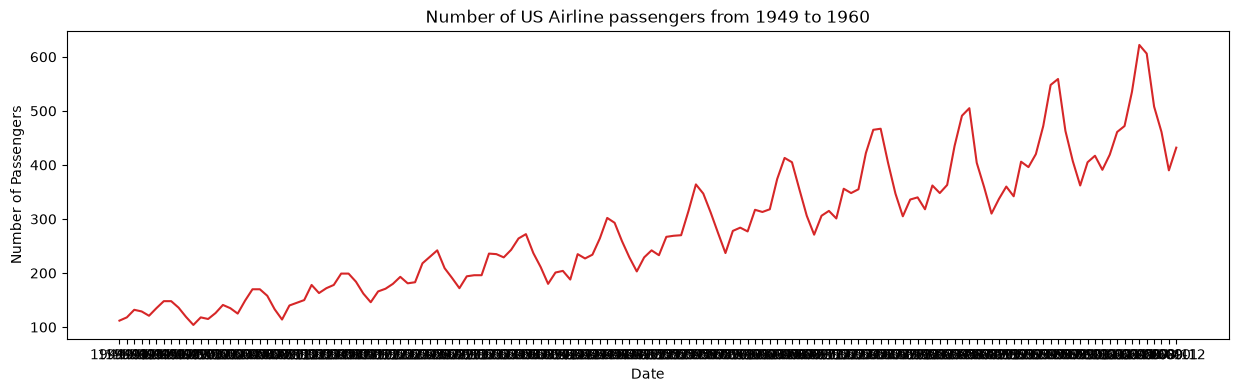

In [5]:
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Number of Passengers', dpi=100):
    plt.figure(figsize=(15,4), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()
    

plot_df(df, x=df['Date'], y=df['Number of Passengers'], title='Number of US Airline passengers from 1949 to 1960')

- Since all the values are positive, we can show this on both sides of the Y axis to emphasize the growth.

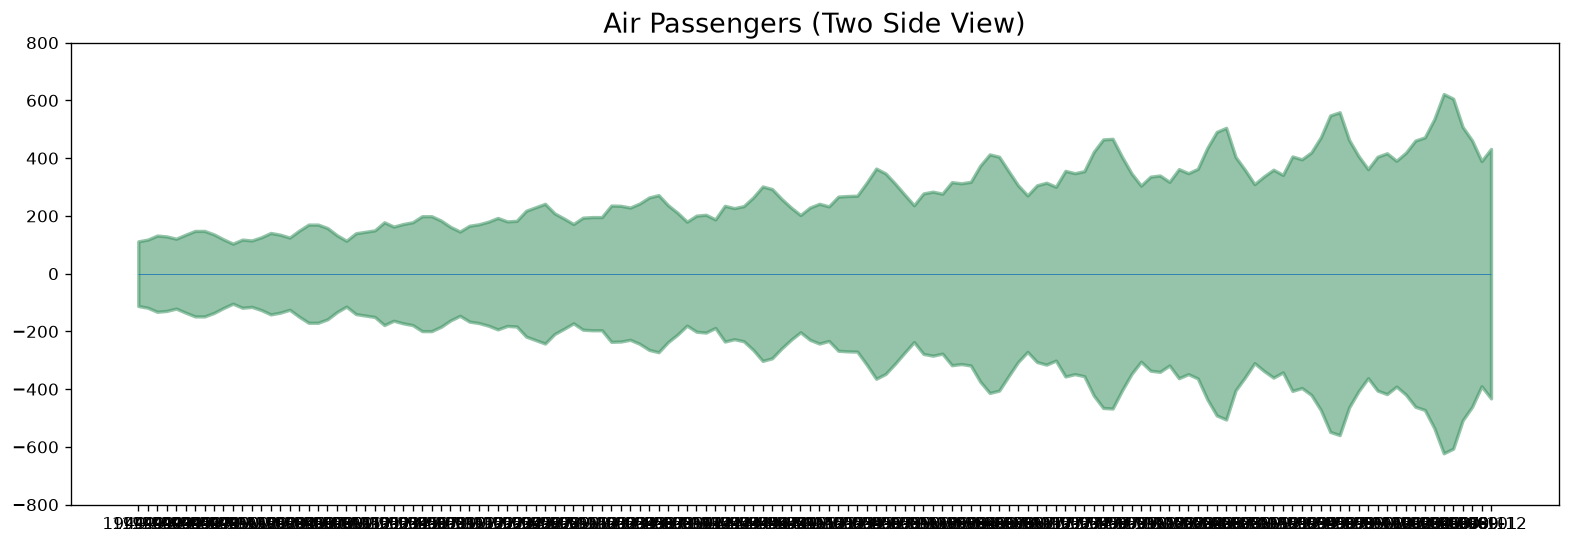

In [6]:
x = df['Date'].values
y1 = df['Number of Passengers'].values

# Plot
fig, ax = plt.subplots(1, 1, figsize=(16,5), dpi= 120)
plt.fill_between(x, y1=y1, y2=-y1, alpha=0.5, linewidth=2, color='seagreen')
plt.ylim(-800, 800)
plt.title('Air Passengers (Two Side View)', fontsize=16)
plt.hlines(y=0, xmin=np.min(df['Date']), xmax=np.max(df['Date']), linewidth=.5)
plt.show()

- It can be seen that its a monthly time series and follows a certain repetitive pattern every year. So, we can plot each year as a separate line in the same plot. This let us compare the year wise patterns side-by-side.

# **6. Patterns in a Time Series** <a class="anchor" id="6"></a>

### **Trend**

- A **trend** is observed when there is an increasing or decreasing slope observed in the time series. 


### **Seasonality**

- A **seasonality** is observed when there is a distinct repeated pattern observed between regular intervals due to seasonal factors. It could be because of the month of the year, the day of the month, weekdays or even time of the day.


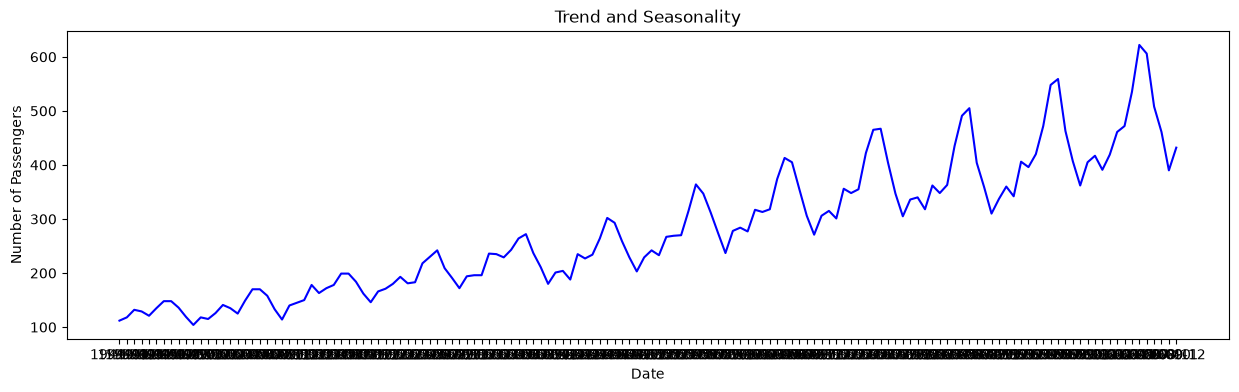

In [7]:
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Number of Passengers', dpi=100):
    plt.figure(figsize=(15,4), dpi=dpi)
    plt.plot(x, y, color='blue')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()
    

plot_df(df, x=df['Date'], y=df['Number of Passengers'], title='Trend and Seasonality')

### **Cyclic behaviour**

- Another important thing to consider is the **cyclic behaviour**. It happens when the rise and fall pattern in the series does not happen in fixed calendar-based intervals. We should not confuse 'cyclic' effect with 'seasonal' effect.

- If the patterns are not of fixed calendar based frequencies, then it is cyclic. Because, unlike the seasonality, cyclic effects are typically influenced by the business and other socio-economic factors.

# **7. Additive and Multiplicative Time Series** <a class="anchor" id="7"></a>

### **Additive time series:**

Value = Base Level + Trend + Seasonality + Error


### **Multiplicative Time Series:**

Value = Base Level x Trend x Seasonality x Error

# **8. Decomposition of a Time Series** <a class="anchor" id="8"></a>





- Decomposition of a time series can be performed by considering the series as an additive or multiplicative combination of the base level, trend, seasonal index and the residual term.


- The seasonal_decompose in statsmodels implements this conveniently.

In [9]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   -----------------

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

print("statsmodels imported successfully!")

statsmodels imported successfully!


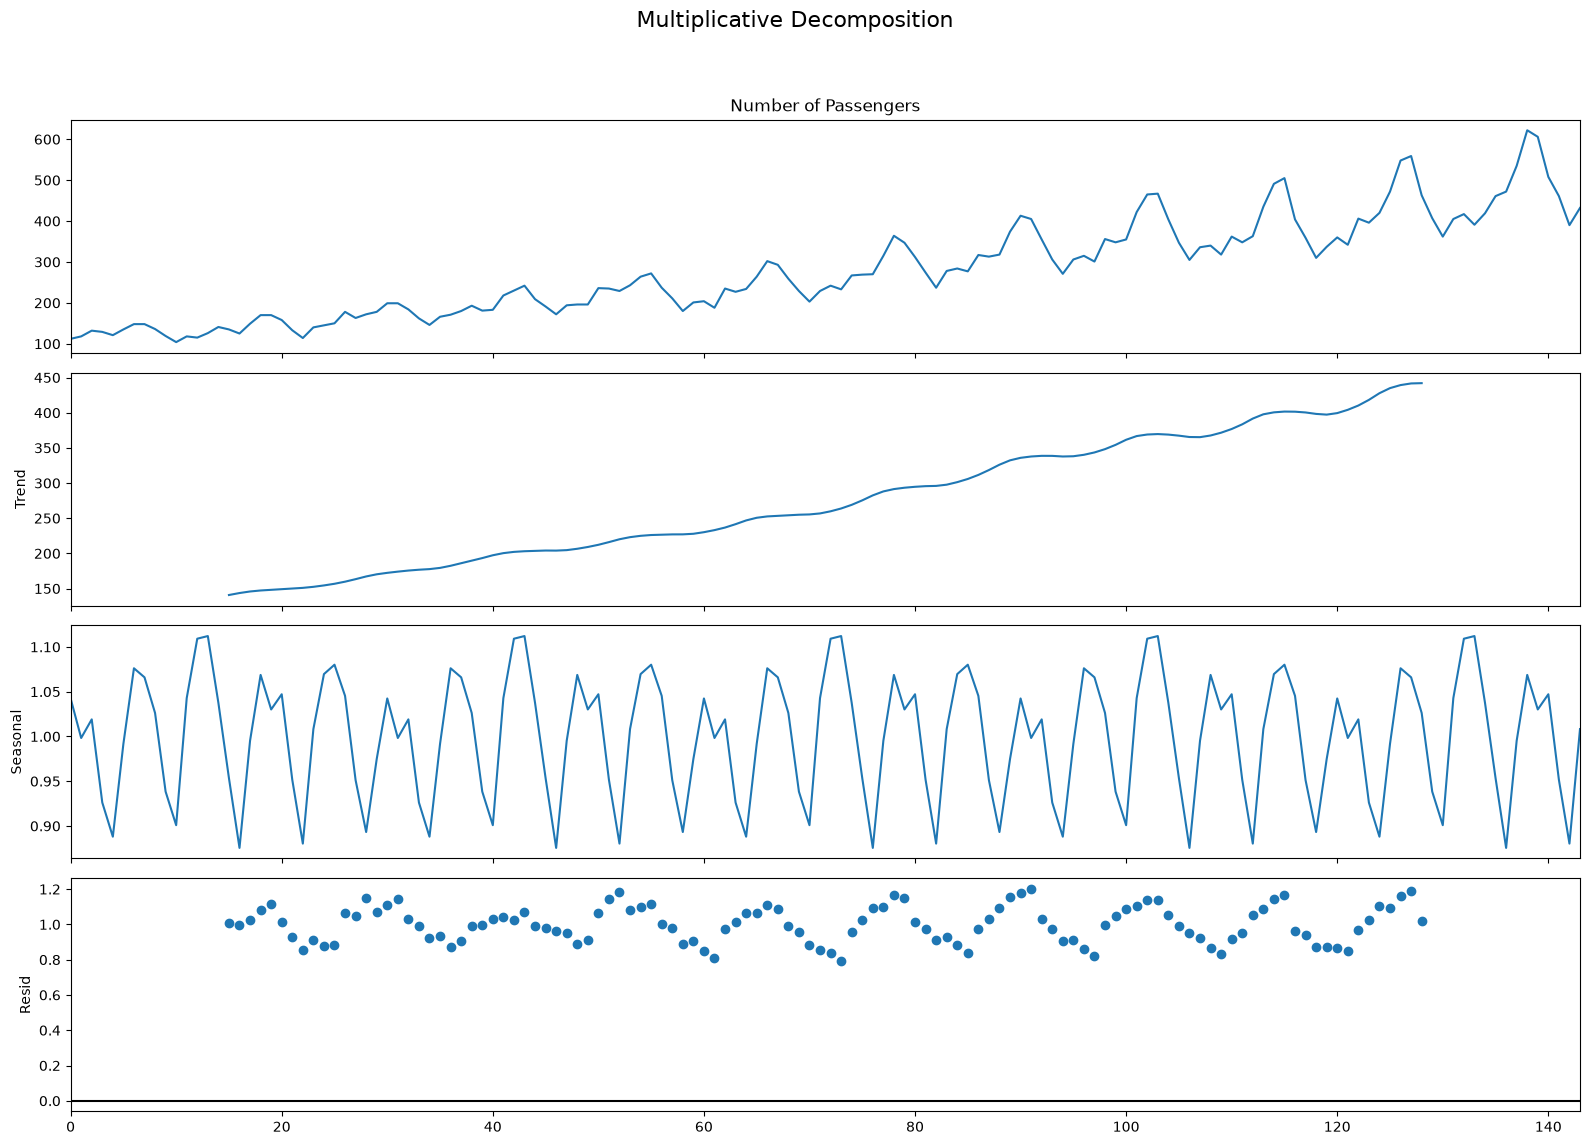

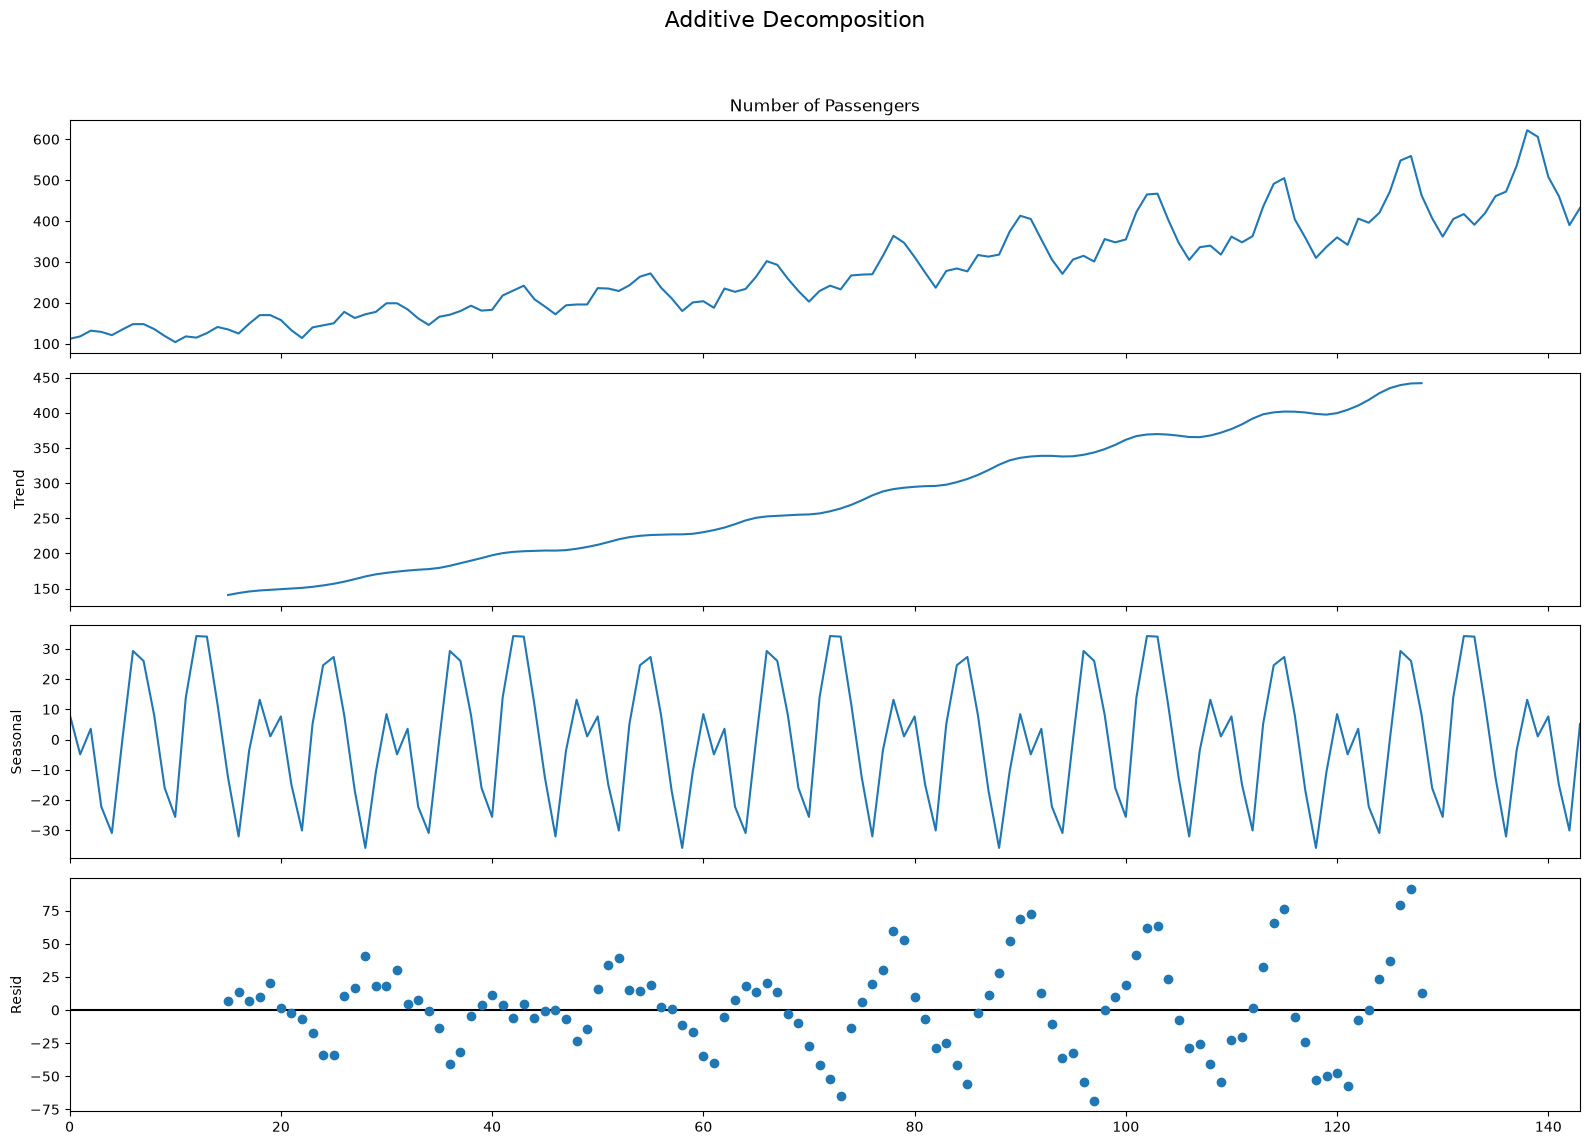

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse


# Multiplicative Decomposition 
multiplicative_decomposition = seasonal_decompose(df['Number of Passengers'], model='multiplicative', period=30)

# Additive Decomposition
additive_decomposition = seasonal_decompose(df['Number of Passengers'], model='additive', period=30)

# Plot
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Multiplicative Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

additive_decomposition.plot().suptitle('Additive Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

- If we look at the residuals of the additive decomposition closely, it has some pattern left over. 

- The multiplicative decomposition, looks quite random which is good. So ideally, multiplicative decomposition should be preferred for this particular series.

# **9. Stationary and Non-Stationary Time Series** <a class="anchor" id="9"></a>



- Now, we wil discuss **Stationary and Non-Stationary Time Series**. **Stationarity** is a property of a time series. A stationary series is one where the values of the series is not a function of time. So, the values are independent of time.


- Hence the statistical properties of the series like mean, variance and autocorrelation are constant over time. Autocorrelation of the series is nothing but the correlation of the series with its previous values.


- A stationary time series is independent of seasonal effects as well.


- Now, we will plot some examples of stationary and non-stationary time series for clarity.

# **10. How to make a time series stationary?** <a class="anchor" id="10"></a>


1. Differencing the Series (once or more)
2. Take the log of the series
3. Take the nth root of the series
4. Combination of the above


- The most commonly used and convenient method to stationarize the series is by differencing the series at least once until it becomes approximately stationary.

## **10.1 Introduction to Differencing** <a class="anchor" id="10.1"></a>



- If Y_t is the value at time t, then the first difference of Y = Yt – Yt-1. In simpler terms, differencing the series is nothing but subtracting the next value by the current value.


- If the first difference doesn’t make a series stationary, we can go for the second differencing and so on.


  - For example, consider the following series: [1, 5, 2, 12, 20]


  - First differencing gives: [5-1, 2-5, 12-2, 20-12] = [4, -3, 10, 8]


  - Second differencing gives: [-3-4, -10-3, 8-10] = [-7, -13, -2]

## **10.2 Reasons to convert a non-stationary series into stationary one before forecasting** <a class="anchor" id="10.2"></a>



There are reasons why we want to convert a non-stationary series into a stationary one. These are given below:


- Forecasting a stationary series is relatively easy and the forecasts are more reliable.


- An important reason is, autoregressive forecasting models are essentially linear regression models that utilize the lag(s) of the series itself as predictors.


# **  Difference between white noise and a stationary series** <a class="anchor" id="12"></a>




- Like a stationary series, the white noise is also not a function of time. So, its mean and variance does not change over time. But the difference is that, the white noise is completely random with a mean of 0. In white noise there is no pattern.

- Mathematically, a sequence of completely random numbers with mean zero is a white noise.

<Axes: title={'center': 'Random White Noise'}>

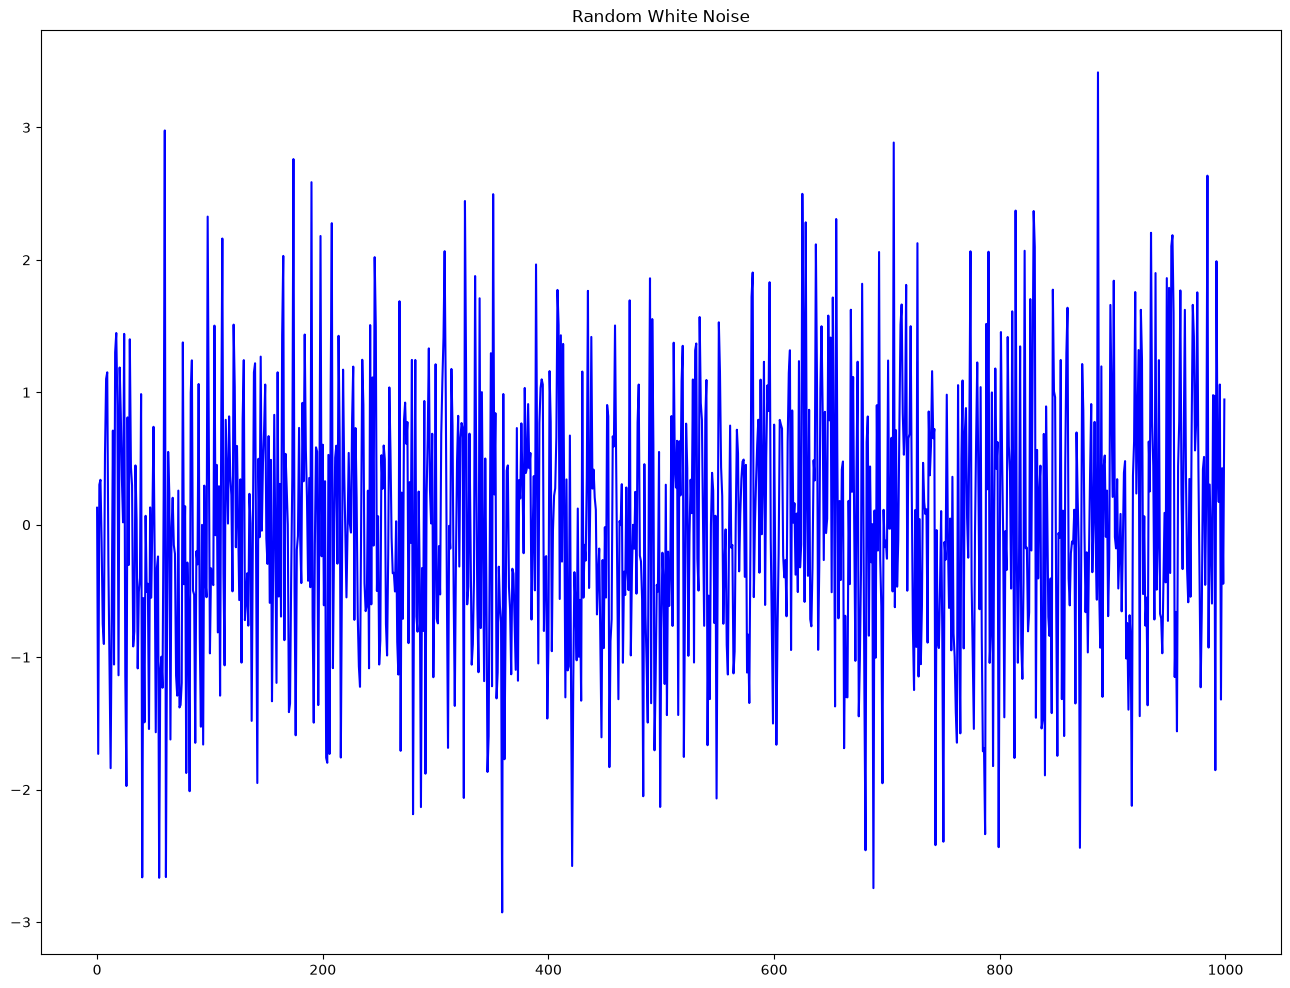

In [12]:
rand_numbers = np.random.randn(1000)
pd.Series(rand_numbers).plot(title='Random White Noise', color='b')

# **13. Detrend a Time Series** <a class="anchor" id="13"></a>


- Detrending a time series means to remove the trend component from the time series. There are multiple approaches of doing this as listed below:


1. Subtract the line of best fit from the time series. The line of best fit may be obtained from a linear regression model with the time steps as the predictor. For more complex trends, we may want to use quadratic terms (x^2) in the model.

2. We subtract the trend component obtained from time series decomposition.

3. Subtract the mean.

4. Apply a filter like Baxter-King filter(statsmodels.tsa.filters.bkfilter) or the Hodrick-Prescott Filter (statsmodels.tsa.filters.hpfilter) to remove the moving average trend lines or the cyclical components.


Now, we will implement the first two methods to detrend a time series.

Text(0.5, 1.0, 'Air Passengers detrended by subtracting the least squares fit')

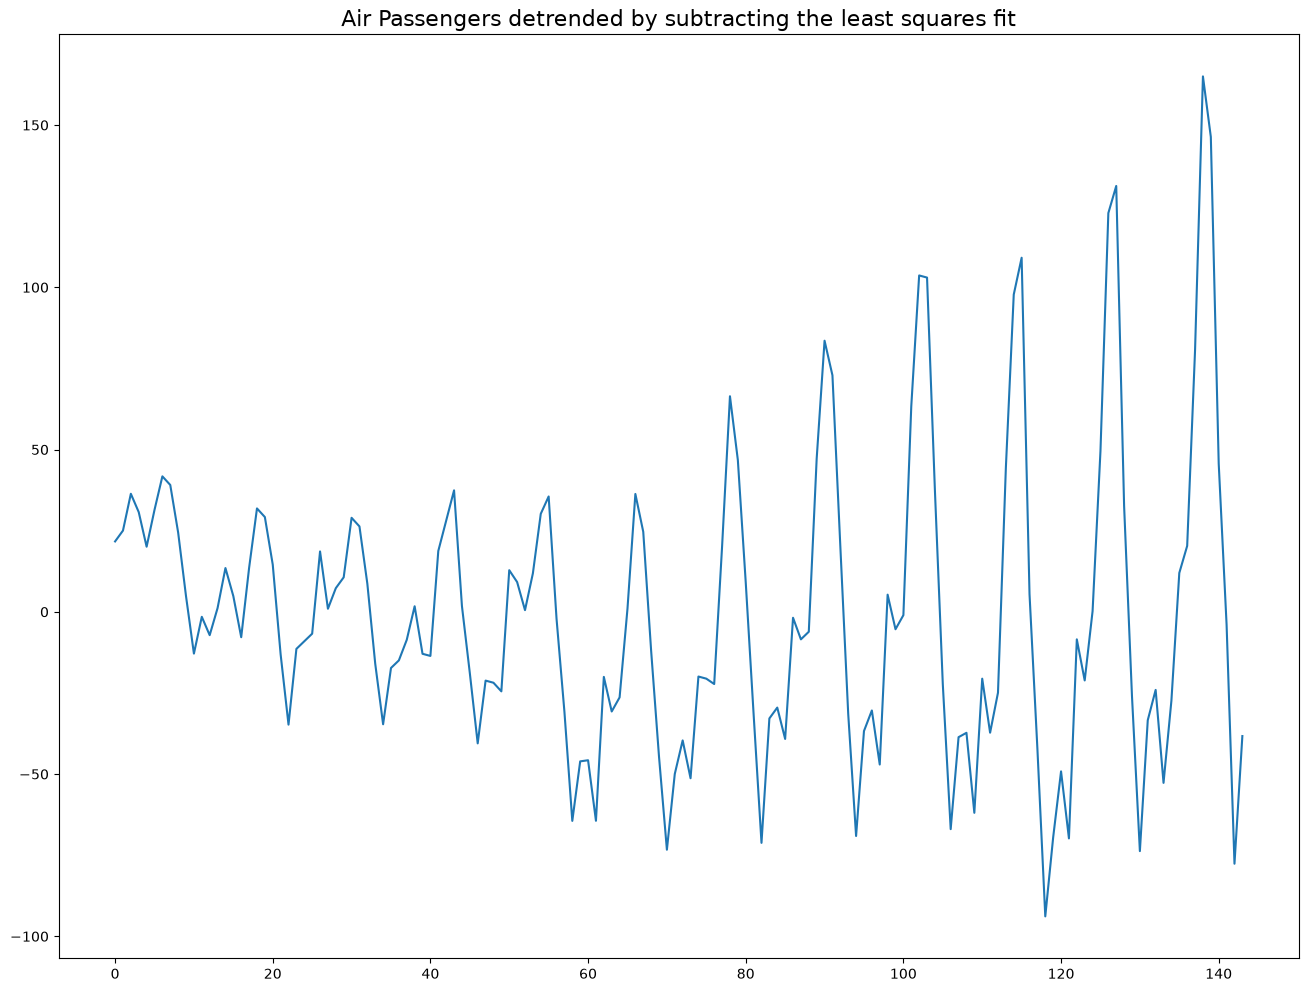

In [13]:
# Using scipy: Subtract the line of best fit
from scipy import signal
detrended = signal.detrend(df['Number of Passengers'].values)
plt.plot(detrended)
plt.title('Air Passengers detrended by subtracting the least squares fit', fontsize=16)

Text(0.5, 1.0, 'Air Passengers detrended by subtracting the trend component')

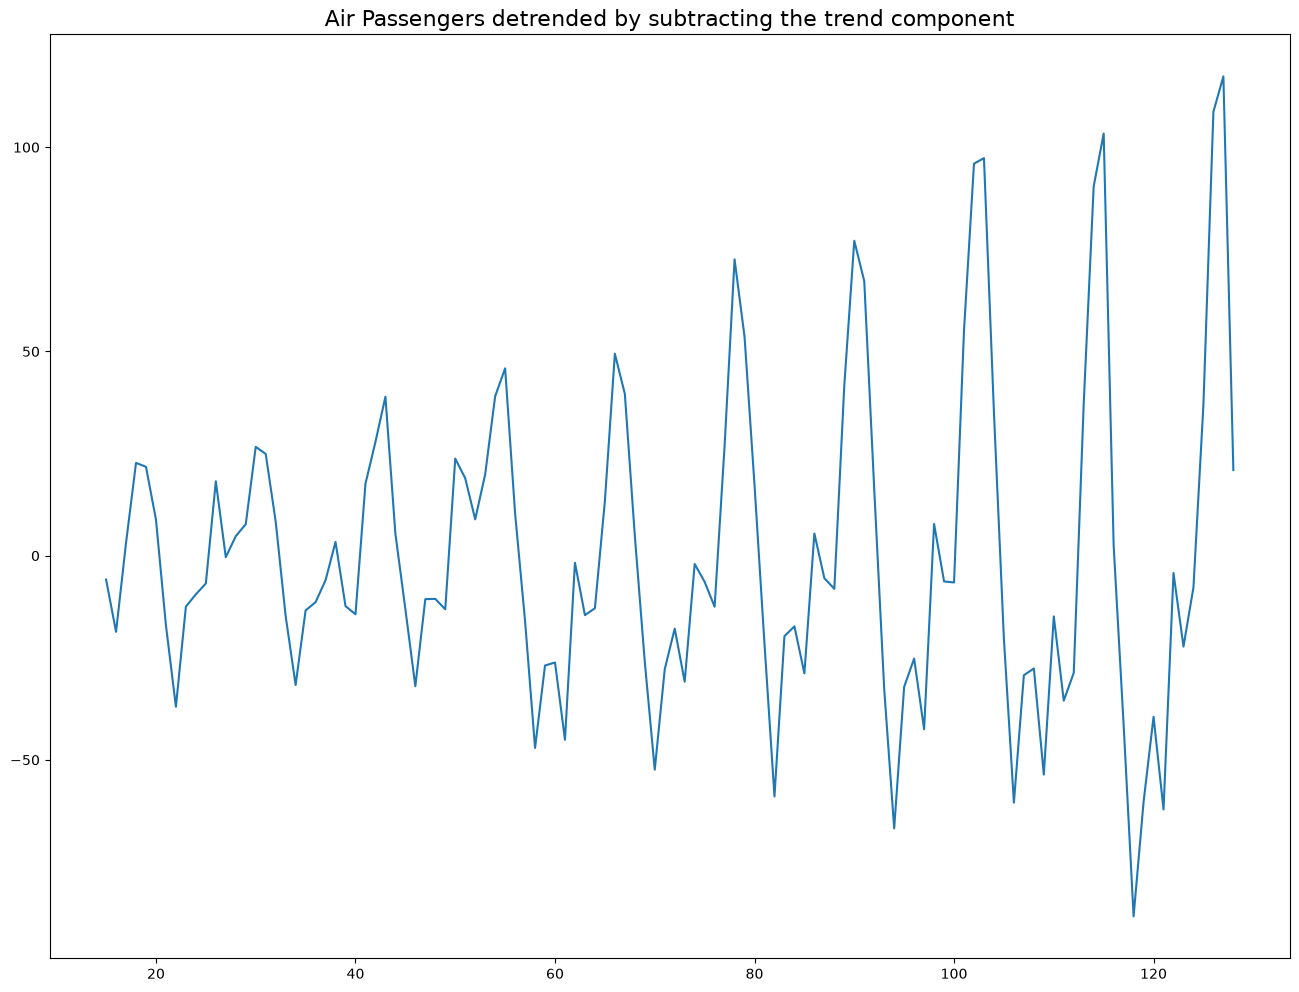

In [14]:
# Using statmodels: Subtracting the Trend Component
from statsmodels.tsa.seasonal import seasonal_decompose
result_mul = seasonal_decompose(df['Number of Passengers'], model='multiplicative', period=30)
detrended = df['Number of Passengers'].values - result_mul.trend
plt.plot(detrended)
plt.title('Air Passengers detrended by subtracting the trend component', fontsize=16)

# **14. Deseasonalize a Time Series** <a class="anchor" id="14"></a>



There are multiple approaches to deseasonalize a time series. These approaches are listed below:


- 1. Take a moving average with length as the seasonal window. This will smoothen in series in the process.

- 2. Seasonal difference the series (subtract the value of previous season from the current value).

- 3. Divide the series by the seasonal index obtained from STL decomposition.




[]

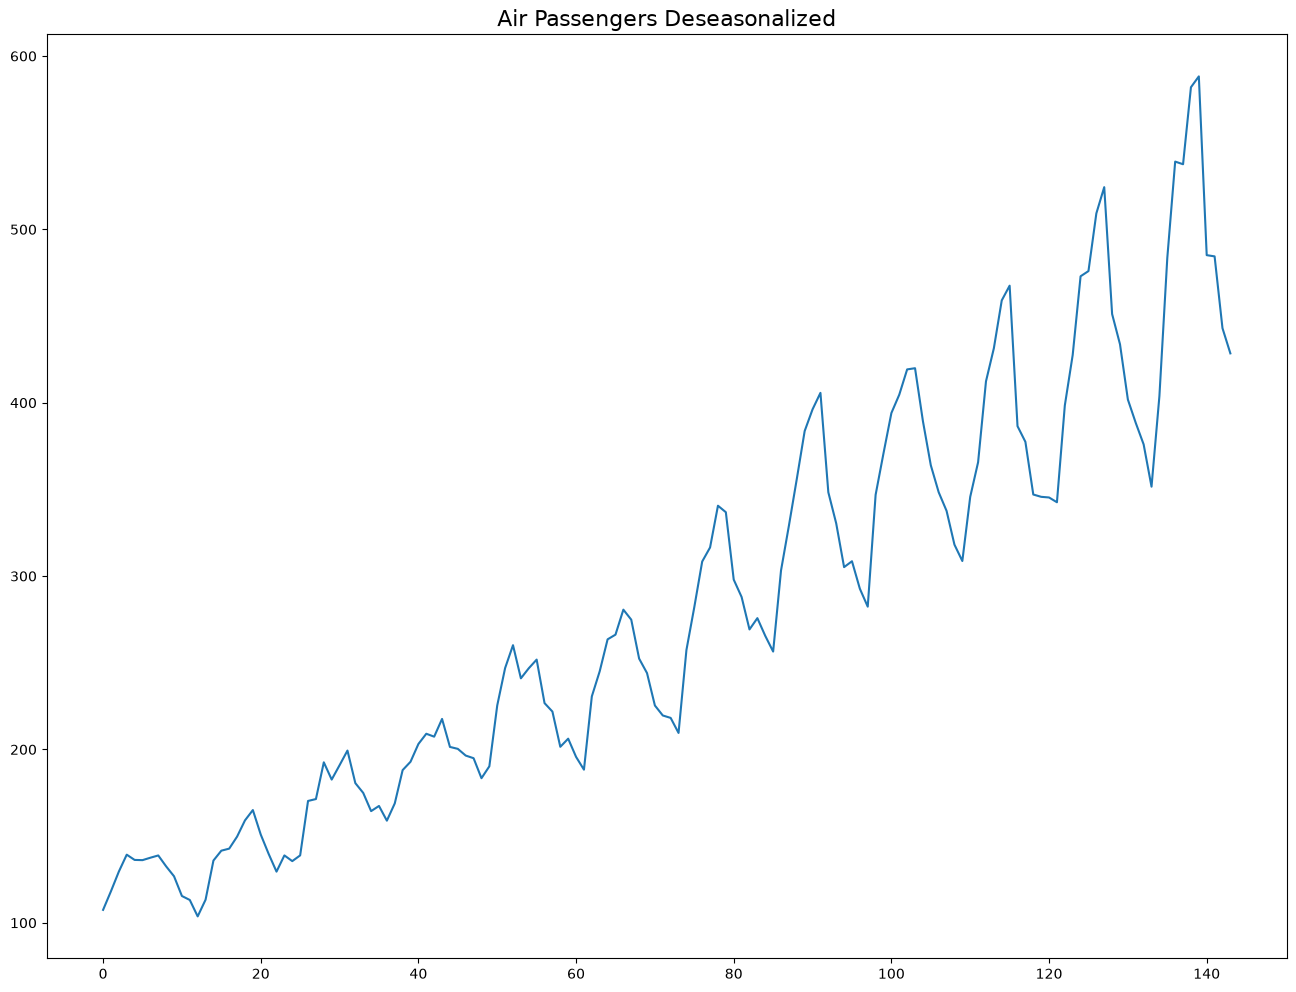

In [15]:
# Subtracting the Trend Component


# Time Series Decomposition
result_mul = seasonal_decompose(df['Number of Passengers'], model='multiplicative', period=30)


# Deseasonalize
deseasonalized = df['Number of Passengers'].values / result_mul.seasonal


# Plot
plt.plot(deseasonalized)
plt.title('Air Passengers Deseasonalized', fontsize=16)
plt.plot()

# **15. How to test for seasonality of a time series?** <a class="anchor" id="15"></a>



The common way to test for seasonality of a time series is to plot the series and check for repeatable patterns in fixed time intervals. So, the types of seasonality is determined by the clock or the calendar.


1. Hour of day
2. Day of month
3. Weekly
4. Monthly
5. Yearly


<Axes: xlabel='Lag', ylabel='Autocorrelation'>

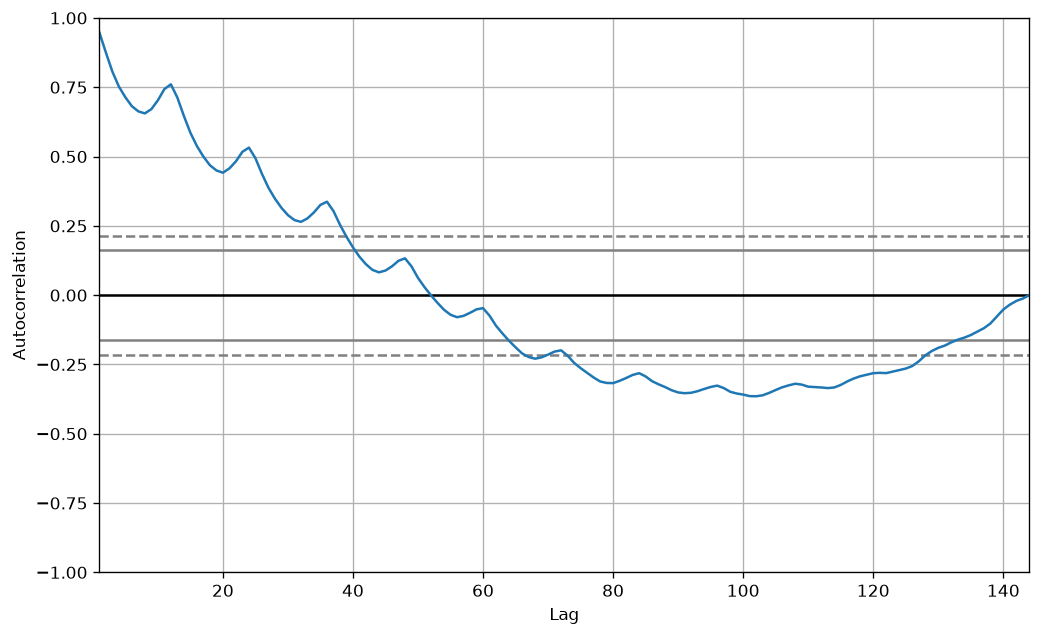

In [16]:
# Test for seasonality
from pandas.plotting import autocorrelation_plot

# Draw Plot
plt.rcParams.update({'figure.figsize':(10,6), 'figure.dpi':120})
autocorrelation_plot(df['Number of Passengers'].tolist())

# **16. Autocorrelation and Partial Autocorrelation Functions** <a class="anchor" id="16"></a>



- **Autocorrelation** is simply the correlation of a series with its own lags. If a series is significantly autocorrelated, that means, the previous values of the series (lags) may be helpful in predicting the current value.


- **Partial Autocorrelation** also conveys similar information but it conveys the pure correlation of a series and its lag, excluding the correlation contributions from the intermediate lags.

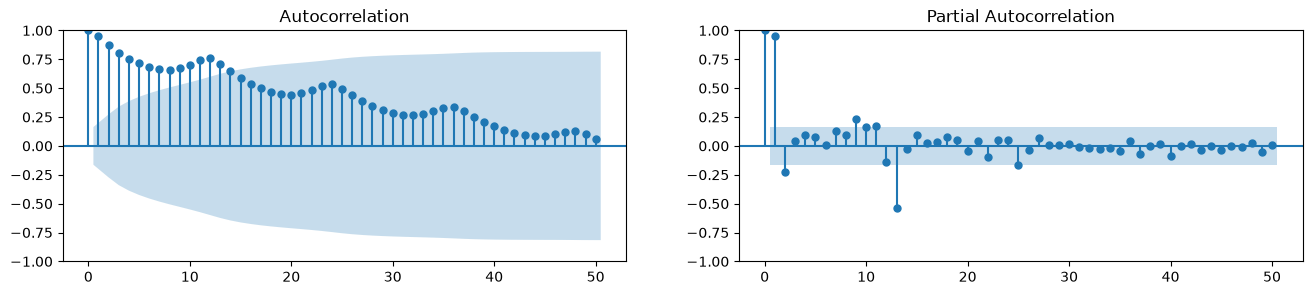

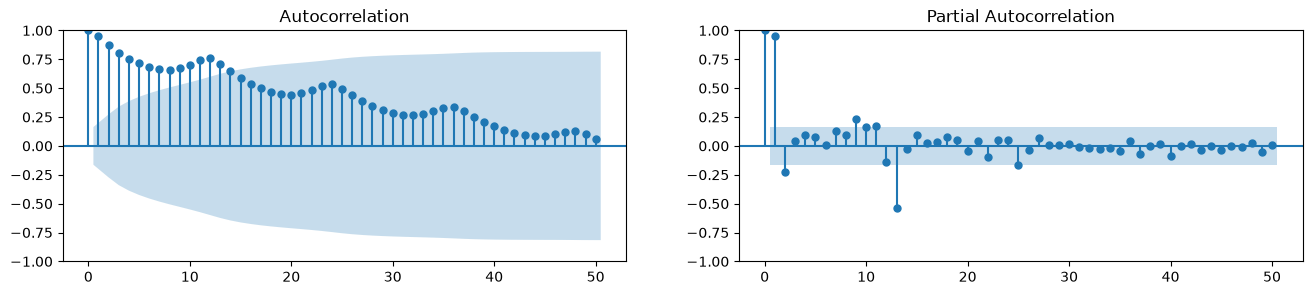

In [17]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Draw Plot
fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(df['Number of Passengers'].tolist(), lags=50, ax=axes[0])
plot_pacf(df['Number of Passengers'].tolist(), lags=50, ax=axes[1])

# **18. Lag Plots** <a class="anchor" id="18"></a>



- A **Lag plot** is a scatter plot of a time series against a lag of itself. It is normally used to check for autocorrelation. If there is any pattern existing in the series, the series is autocorrelated. If there is no such pattern, the series is likely to be random white noise.


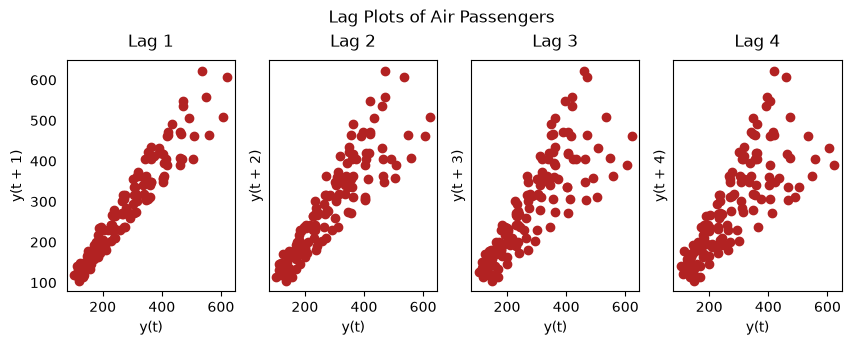

In [18]:
from pandas.plotting import lag_plot
plt.rcParams.update({'ytick.left' : False, 'axes.titlepad':10})

# Plot
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(df['Number of Passengers'], lag=i+1, ax=ax, c='firebrick')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle('Lag Plots of Air Passengers', y=1.05)    
plt.show()

# **19. Granger Causality Test** <a class="anchor" id="19"></a>


- **Granger causality test** is used to determine if one time series will be useful to forecast another. It is based on the idea that if X causes Y, then the forecast of Y based on previous values of Y AND the previous values of X should outperform the forecast of Y based on previous values of Y alone.


- So, **Granger causality test** should not be used to test if a lag of Y causes Y. Instead, it is generally used on exogenous (not Y lag) variables only. It is implemented in the statsmodel package.



In [22]:
import pandas as pd

data = pd.read_csv(
    r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\AirPassengers.csv"
)

print(data.columns)
print(data.head())

Index(['Month', '#Passengers'], dtype='str')
     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121


In [23]:
from statsmodels.tsa.stattools import grangercausalitytests
import pandas as pd

# Load dataset
data = pd.read_csv(
    r"D:\ML\Machine learning\time-series-analysis-and-lstm\data\AirPassengers.csv"
)

# Convert Month to datetime
data["Month"] = pd.to_datetime(data["Month"])

# Extract month number
data["month"] = data["Month"].dt.month

# Granger Causality Test
grangercausalitytests(
    data[["#Passengers", "month"]],
    maxlag=2
)

{np.int64(1): ({'ssr_ftest': (np.float64(7.407967762077246),
    np.float64(0.007318844731632713),
    np.float64(140.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(7.566709928407473),
    np.float64(0.005945621865036116),
    np.int64(1)),
   'lrtest': (np.float64(7.373310381387228),
    np.float64(0.00661989587473731),
    np.int64(1)),
   'params_ftest': (np.float64(7.407967762077289),
    np.float64(0.0073188447316325485),
    np.float64(140.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(4.9760839229064695),
    np.float64(0.008199795902675536),
    np.float64(137.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(10.315385650404652),
    np.float64(0.005754962083917233),
    np.int64(2)),
   'lrtest': (np.float64(9.957923125859452),
    np.float64(0.006881204546490603),
    np.int64(2)),
   'params_ftest': (np.float64(4.976083922906415),
    np.float64(0.008199795902675944),
    np.float64(137.0),
    2.0)},
   array([[0., 0., 1., 0., 0

- In the above case, the p-values are zero for all tests. So the ‘month’ indeed can be used to forecast the values.

# **20. Smoothening a Time Series** <a class="anchor" id="20"></a>



Smoothening of a time series may be useful in the following circumstances:


- Reducing the effect of noise in a signal get a fair approximation of the noise-filtered series.
- The smoothed version of series can be used as a feature to explain the original series itself.
- Visualize the underlying trend better.


We can smoothen a time series using the following methods:


- Take a moving average
- Do a LOESS smoothing (Localized Regression)
- Do a LOWESS smoothing (Locally Weighted Regression)

## **Moving Average** 


- **Moving average** is the average of a rolling window of defined width. We must choose the window-width wisely, because, large window-size will over-smooth the series. For example, a window-size equal to the seasonal duration (ex: 12 for a month-wise series), will effectively nullify the seasonal effect.
 

## **Localized Regression**


- LOESS, short for ‘Localized Regression’ fits multiple regressions in the local neighborhood of each point. It is implemented in the statsmodels package, where you can control the degree of smoothing using frac argument which specifies the percentage of data points nearby that should be considered to fit a regression model.

# 🎯 Conclusion

Time Series Analysis helps us understand how data changes over time and identify important patterns such as **trend, seasonality, cycles, and noise**.

In this notebook, we explored important concepts including **time series visualization, decomposition, stationarity, ADF/KPSS tests, detrending, deseasonalization, ACF, PACF, lag plots, Granger causality, and smoothing**.

These techniques provide a strong foundation for understanding historical time-dependent data and preparing it for **forecasting and machine learning models**.

The concepts learned here will also help in the next stage of this project: **LSTM-based Time Series Forecasting**, where deep learning is used to learn patterns from sequential data and make future predictions.

**📈 Understand the past → Discover patterns → Prepare the data → Forecast the future**

**Created by: Ajim Mujawar**
